# *Aspergillus niger* — Fungal Pathogen Model

**Phase 1A:** Characterisation of the *A. niger* GEM as a preparatory step for host-pathogen simulations with *Vitis vinifera* berry.

---
* **Author:** Joana Maia
* **Solver:** Gurobi (Academic Licence)
* **Core libraries:** COBRApy · Pandas · Seaborn · Matplotlib
* **Model:** *iJB1325* — *Aspergillus niger*

---

## 1. Environment Setup
### 1.1 Package Installation
Install/verify required packages.

In [1]:
# !pip install cobra
# !pip install gurobipy
# !pip install matplotlib
# !pip install pandas
# !pip install seaborn

### 1.2 Library Imports and Version Audit
Import all dependencies and record library versions for reproducibility.

In [2]:
# Standard library
import os
import warnings
warnings.filterwarnings('ignore')

# Numerical / data
import numpy as np
import pandas as pd

# Visualisation
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# COBRApy and flux analysis tools
import cobra
from cobra.flux_analysis import (find_blocked_reactions, find_essential_genes, find_essential_reactions, flux_variability_analysis, production_envelope)
from cobra.io import read_sbml_model, write_sbml_model
import gurobipy

# Version audit
print(f'COBRApy    : {cobra.__version__}')
print(f'Gurobi     : {".".join(str(v) for v in gurobipy.gurobi.version())}')
print(f'Matplotlib : {matplotlib.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'Pandas     : {pd.__version__}')
print(f'Seaborn    : {sns.__version__}')

COBRApy    : 0.31.1
Gurobi     : 13.0.2
Matplotlib : 3.10.8
NumPy      : 2.4.4
Pandas     : 2.3.3
Seaborn    : 0.13.2


### 1.3 Global Plotting Style
Set consistent visual theme for all figures in this notebook.

In [3]:
sns.set_theme(style = 'whitegrid', context = 'notebook', font_scale = 1.1)
plt.rcParams.update({'figure.dpi'         : 120,
                     'axes.spines.top'    : False,
                     'axes.spines.right'  : False,
                     'figure.autolayout'  : True})
PALETTE_MAIN = 'BuPu_r'
PALETTE_CAT  = sns.color_palette('BuPu_r', 8) 

### 1.4 Model Loading
Load *iJB1325* from SBML, copy into `An_model` for analysis and store key boundary reaction IDs.

In [4]:
AN_MODEL_PATH = '40694_2018_60_MOESM2_ESM.xml'

if not os.path.exists(AN_MODEL_PATH):
    raise FileNotFoundError(f'Model file not found: {AN_MODEL_PATH}')

An_raw   = read_sbml_model(AN_MODEL_PATH)
An_model = An_raw.copy()

print(An_model)
print(f'Unconstrained μ (An_raw): {An_raw.optimize().objective_value:.4f} h⁻¹')

'' is not a valid SBML 'SId'.


Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2747228
Academic license 2747228 - for non-commercial use only - registered to pg___@uminho.pt
Read LP format model from file /var/folders/zr/ls8263wn1l7b0wb53pbrcv9r0000gn/T/tmpx6aqcsz2.lp
Reading time = 0.01 seconds
: 1818 rows, 4640 columns, 16506 nonzeros

Unconstrained μ (An_raw): 0.9399 h⁻¹


In [5]:
def _find_boundary(keywords, model = None):
    if model is None:
        model = An_model
    for rxn in model.exchanges:
        if any(k.upper() in rxn.id.upper() for k in keywords):
            return rxn.id
    for rxn in model.reactions:
        if rxn.id.startswith('BOUNDARY_'):
            if any(k.upper() in rxn.id.upper() for k in keywords):
                return rxn.id
    return None

GROWTH_R2_AN        = None
min_rate_AN         = None

BIOMASS_RXN = 'DRAIN_Biomass'
CO2_RXN     = _find_boundary(['BOUNDARY_CO2'])    or 'BOUNDARY_CO2e'
GLC_RXN     = _find_boundary(['BOUNDARY_GLC'])    or 'BOUNDARY_GLCe'
H2O_RXN     = _find_boundary(['BOUNDARY_H2Oe'])   or 'BOUNDARY_H2Oe'
NO3_RXN     = _find_boundary(['BOUNDARY_HNO3'])   or 'BOUNDARY_HNO3e'
O2_RXN      = _find_boundary(['BOUNDARY_O2'])     or 'BOUNDARY_O2e'

print('Global reaction ID configuration:')
print(f'  BIOMASS_RXN : {BIOMASS_RXN}')
print(f'  CO₂_RXN     : {CO2_RXN}')
print(f'  GLC_RXN     : {GLC_RXN}')
print(f'  H₂O_RXN     : {H2O_RXN}')
print(f'  NO₃_RXN     : {NO3_RXN}')
print(f'  O₂_RXN      : {O2_RXN}')

Global reaction ID configuration:
  BIOMASS_RXN : DRAIN_Biomass
  CO₂_RXN     : BOUNDARY_CO2e
  GLC_RXN     : BOUNDARY_GLCe
  H₂O_RXN     : BOUNDARY_H2Oe
  NO₃_RXN     : BOUNDARY_HNO3e
  O₂_RXN      : BOUNDARY_O2e


## 2. Global Characterisation
### 2.1 Initial Metabolic Summary
Generate an overview of the metabolic model, including growth performance and major exchange fluxes.

In [6]:
An_model.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
GLCe,BOUNDARY_GLCe,10,6,100.00%
HNO3e,BOUNDARY_HNO3e,3.886,0,0.00%
O2e,BOUNDARY_O2e,7.778,0,0.00%
PIe,BOUNDARY_PIe,0.115,0,0.00%
SLFe,BOUNDARY_SLFe,0.04548,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
CO2e,BOUNDARY_CO2e,-18.39,1,100.00%
H2Oe,BOUNDARY_H2Oe,-26.37,0,0.00%
He,BOUNDARY_He,-0.0112,0,0.00%
BIOMASS,DRAIN_Biomass,-0.9399,0,0.00%


### 2.2 Objective Function
Identify the biomass reaction used as the FBA objective.

In [7]:
obj_rxn = An_model.reactions.get_by_id(BIOMASS_RXN)

print(f'Objective reaction : {obj_rxn.id}')
print(f'Direction          : {"Maximise" if An_model.objective.direction == "max" else "Minimise"}')
print(f'Bounds             : [{obj_rxn.lower_bound}, {obj_rxn.upper_bound}]')
print(f'Full objective     : {An_model.objective.expression}')

Objective reaction : DRAIN_Biomass
Direction          : Maximise
Bounds             : [0.0, 1000.0]
Full objective     : 1.0*DRAIN_Biomass - 1.0*DRAIN_Biomass_reverse_fcc30


### 2.3 Optimal Flux Simulation via FBA
Run FBA to obtain the maximum growth rate (μ) and exchange flux profile under default exchange bounds.

In [8]:
fba_solution = An_model.optimize()
print(f'FBA status : {fba_solution.status}')
print(f'μ (h⁻¹)    : {fba_solution.objective_value:.4f}')

# Update baseline fluxes from FBA solution
GLC_BASELINE_AN = abs(fba_solution.fluxes.get(GLC_RXN, 0.0))
NO3_BASELINE_AN = abs(fba_solution.fluxes.get(NO3_RXN, 0.0))
O2_BASELINE_AN  = abs(fba_solution.fluxes.get(O2_RXN,  0.0))

print(f'\nGlucose uptake : {GLC_BASELINE_AN:.4f} mmol/gDW/h')
print(f'NO₃ uptake     : {NO3_BASELINE_AN:.4f} mmol/gDW/h')
print(f'O₂ uptake      : {O2_BASELINE_AN:.4f} mmol/gDW/h')

FBA status : optimal
μ (h⁻¹)    : 0.9399

Glucose uptake : 10.0000 mmol/gDW/h
NO₃ uptake     : 3.8856 mmol/gDW/h
O₂ uptake      : 7.7792 mmol/gDW/h


### 2.4 Compartment Mapping
Map internal compartment identifiers to biological names.

In [9]:
print('Compartments in iJB1325:')
for cid, cname in sorted(An_model.compartments.items()):
    print(f'  {cid} : {cname}')

# Verify extracellular compartment is 'e'
assert 'e' in An_model.compartments, "Extracellular compartment 'e' not found."
print('\nExtracellular compartment [e] confirmed.')

Compartments in iJB1325:
  c : Cytoplasm
  e : Extracellular
  g : Golgi
  m : Mitochondria
  n : Nucleus
  p : Peroxisome
  v : Vacuole

Extracellular compartment [e] confirmed.


### 2.5 Culture Medium
Display the default exchange bounds of the model.

**Note:**  Glucose is the only effectively constrained nutrient (Uptake limit = $-10 mmol/gDW/h$); all other exchange reactions carry the default open bound of $1000 mmol/gDW/h$ — effectively unlimited. Glucose is therefore the sole growth-limiting carbon source in the default medium.

In [10]:
medium_df = (pd.DataFrame.from_dict(An_model.medium, orient = 'index', columns = ['Upper bound'])
             .rename_axis('Boundary reaction')
             .sort_values('Upper bound', ascending = False))

print(f'Boundary reactions in medium: {len(medium_df)}')

print(f'\n{"Reaction":<15} {"Uptake limit":>20} {"Secretion limit":>20}')
print('_' * 60)
for rxn_id in medium_df.index:
    rxn = An_model.reactions.get_by_id(rxn_id)
    print(f'{rxn_id:<15} {rxn.lower_bound:>20.1f} {rxn.upper_bound:>20.1f}')

Boundary reactions in medium: 8

Reaction                Uptake limit      Secretion limit
____________________________________________________________
BOUNDARY_H2Oe                -1000.0               1000.0
BOUNDARY_HNO3e               -1000.0               1000.0
BOUNDARY_O2e                 -1000.0               1000.0
BOUNDARY_PIe                 -1000.0               1000.0
BOUNDARY_SLFe                -1000.0               1000.0
BOUNDARY_Ke                  -1000.0               1000.0
BOUNDARY_CAe                 -1000.0               1000.0
BOUNDARY_GLCe                  -10.0               1000.0


## 3. Network Topology
### 3.1 Global Statistics
Summarise the total counts of reactions, metabolites, and genes to outline the global network topology of the model.

In [11]:
n_genes      = len(An_model.genes)
n_mets       = len(An_model.metabolites)
n_comps      = len(An_model.compartments)
n_rxns       = len(An_model.reactions)
n_ex         = len(An_model.exchanges)
bound_as_ex  = [r for r in An_model.exchanges if r.id.startswith('BOUNDARY_')]
non_boundary = [r for r in An_model.exchanges if not r.id.startswith('BOUNDARY_')]
n_dem        = len(An_model.demands)
n_snk        = len(An_model.sinks)
n_gpr        = sum(1 for r in An_model.reactions if r.gene_reaction_rule.strip())
orphan       = [r for r in An_model.reactions 
                if r.gene_reaction_rule.strip() and not r.genes]

print(f'Genes                          : {n_genes}')
print(f'Metabolites                    : {n_mets}')
print(f'Compartments                   : {n_comps}')
print(f'Reactions                      : {n_rxns}')
print(f'Exchange reactions             : {n_ex}')
print(f'    BOUNDARY_ reactions counted as exchanges        : {len(bound_as_ex)}')
print(f'    Only non BOUNDARY_ reaction counted as exchange : {non_boundary}')
print(f'Demand reactions               : {n_dem}')
for r in An_model.demands:
    print(f'    {r.id:<15} : {r.name}')
print(f'Sink reactions                 : {n_snk}')
print(f'Reactions with GPR rules       : {n_gpr}')
print(f'GPR rules without mapped genes : {len(orphan)}')

Genes                          : 1325
Metabolites                    : 1818
Compartments                   : 7
Reactions                      : 2320
Exchange reactions             : 375
    BOUNDARY_ reactions counted as exchanges        : 374
    Only non BOUNDARY_ reaction counted as exchange : [<Reaction RPRUNe at 0x13982a4c0>]
Demand reactions               : 10
    DRAIN_Biomass   : 
    DRAIN_Pool      : Artificial reaction
    DRAIN_PROTEIN   : Artificial reaction
    DRAIN_LIPIDS    : Artificial reaction
    DRAIN_CELLWALL  : Artificial reaction
    DRAIN_DNA       : Artificial reaction
    DRAIN_DNAm      : Artificial reaction
    DRAIN_RNA       : Artificial reaction
    DRAIN_RNAm      : Artificial reaction
    BOUNDARY_bLARAB : 
Sink reactions                 : 0
Reactions with GPR rules       : 1331
GPR rules without mapped genes : 0


### 3.2 Metabolite and Reaction Catalogues
List all metabolites and reactions.

In [12]:
# Metabolite catalogue
df_metabolites = pd.DataFrame([{'ID': m.id, 'Name': m.name, 'Formula': m.formula,
                                'Compartment': m.compartment, 'Charge': m.charge}
                                for m in An_model.metabolites])

# Reaction catalogue
df_reactions = pd.DataFrame([{'ID': r.id, 'Name': r.name, 'GPR Rule': r.gene_reaction_rule,
                              'Subsystem': r.subsystem, 'LB': r.lower_bound, 'UB': r.upper_bound}
                              for r in An_model.reactions])

# Uncomment to export
# df_metabolites.to_excel('An_metabolites.xlsx', index = False)
# df_reactions.to_excel('An_reactions.xlsx', index = False)

## 4. Essentiality Analysis
### 4.1 Essential Reactions
Essential reactions were identified using **single-reaction deletion** analysis. Reactions whose removal prevented biomass formation were classified as essential.

In [13]:
essential_rxns = find_essential_reactions(An_model, processes = 1)
n_ess          = len(essential_rxns)
print(f'Essential reactions : {n_ess} ({n_ess/n_rxns*100:.1f}% of {n_rxns})')
print(f'Non-essential       : {n_rxns - n_ess} ({(n_rxns-n_ess)/n_rxns*100:.1f}%)')

Essential reactions : 249 (10.7% of 2320)
Non-essential       : 2071 (89.3%)


### 4.2 Gene Essentiality
Essential genes were identified using **single-gene deletion** analysis. Genes whose deletion abolished growth were classified as essential. The analysis also evaluated the coverage of GPR associations across reactions.

Total genes              : 1325
Essential genes          : 140 (10.6%)
Non-essential genes      : 1185 (89.4%)
Reactions with GPR rules : 1331


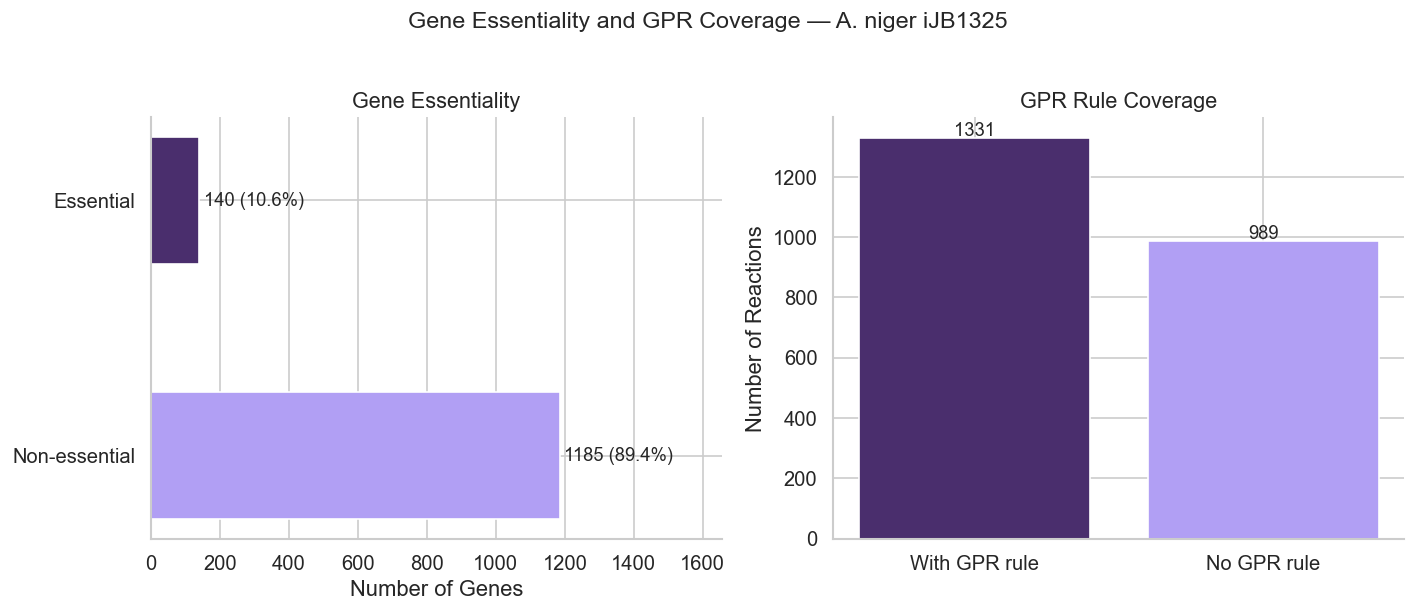

In [14]:
essential_genes_An    = find_essential_genes(An_model, processes = 1)
essential_gene_ids_An = {g.id for g in essential_genes_An}
n_ess_genes           = len(essential_gene_ids_An)

print(f'Total genes              : {n_genes}')
print(f'Essential genes          : {n_ess_genes} ({n_ess_genes/n_genes*100:.1f}%)')
print(f'Non-essential genes      : {n_genes - n_ess_genes} ({(n_genes-n_ess_genes)/n_genes*100:.1f}%)')
print(f'Reactions with GPR rules : {n_gpr}')

n_no_gpr  = n_rxns - n_gpr
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# Left
axes[0].barh(['Non-essential', 'Essential'],
             [n_genes - n_ess_genes, n_ess_genes],
             color     = ['#B19FF4', '#4A2E6D'], 
             edgecolor = 'white', 
             height    = 0.5)
for bar, val, pct in zip(axes[0].patches,
                         [n_genes - n_ess_genes, n_ess_genes],
                         [(n_genes-n_ess_genes)/n_genes*100, n_ess_genes/n_genes*100]):
    axes[0].text(bar.get_width() + n_genes*0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val} ({pct:.1f}%)', 
                 va = 'center', 
                 fontsize = 11)
axes[0].set_xlim(0, n_genes * 1.25)
axes[0].set_xlabel('Number of Genes')
axes[0].set_title('Gene Essentiality', fontsize = 13)

# Right
axes[1].bar(['With GPR rule', 'No GPR rule'], 
            [n_gpr, n_no_gpr],
            color     = ['#4A2E6D', '#B19FF4'], 
            edgecolor = 'white')
axes[1].set_title('GPR Rule Coverage', fontsize = 13)
axes[1].set_ylabel('Number of Reactions')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5, str(int(bar.get_height())),
                 ha = 'center', 
                 fontsize = 11)

plt.suptitle('Gene Essentiality and GPR Coverage — A. niger iJB1325', fontsize = 14, y = 1.02)
plt.tight_layout()
# plt.savefig('fig1_An_gene_essentiality.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## 5. Model Consistency
### 5.1 Blocked Reactions
Identify reactions unable to carry flux under the default medium and distinguish structural blocks (network gaps — metabolites produced but not consumed, or vice versa) from environmentally constrained reactions using a rich-medium simulation.

In [15]:
blocked_ids = find_blocked_reactions(An_model, processes = 1) 
n_blocked   = len(blocked_ids)

with An_model:
    for rxn in An_model.exchanges:
        rxn.lower_bound = -1000
    blocked_rich = find_blocked_reactions(An_model, processes = 1)

n_struct  = len(blocked_rich)
n_environ = n_blocked - n_struct

print(f'Blocked reactions (default medium) : {n_blocked} ({n_blocked/n_rxns*100:.1f}%)')
print(f'Structurally blocked               : {n_struct} ({n_struct/n_rxns*100:.1f}%)')
print(f'Environmentally blocked            : {n_environ} ({n_environ/n_rxns*100:.1f}%)')

Blocked reactions (default medium) : 662 (28.5%)
Structurally blocked               : 372 (16.0%)
Environmentally blocked            : 290 (12.5%)


### 5.2 Mass Balance Validation
Assess stoichiometric consistency. 

In [16]:
bad_rxns = [{'ID': r.id, 'Name': r.name, 'Errors': str(r.check_mass_balance())}
             for r in An_model.reactions if r.check_mass_balance()]
df_bad = pd.DataFrame(bad_rxns)
n_bad  = len(df_bad)

non_internal_ids = ({r.id for r in An_model.exchanges} |
                    {r.id for r in An_model.demands}   |
                    {r.id for r in An_model.sinks})

is_artificial = df_bad['Name'].str.contains('[Aa]rtificial', na=False)
df_internal_bad = df_bad[~df_bad['ID'].isin(non_internal_ids) & ~is_artificial]

n_bound   = n_bad - len(df_internal_bad)
n_int_bad = len(df_internal_bad)

print(f'Reactions with mass discrepancies : {n_bad}')
print(f'    Boundary/artificial : {n_bound}')
print(f'    Internal reactions  : {n_int_bad}')

Reactions with mass discrepancies : 450
    Boundary/artificial : 379
    Internal reactions  : 71


### 5.3 Flux Variability Analysis
FVA at `fraction_of_optimum=0.0` identifies structurally unbounded reactions and 
potential thermodynamic cycles. FVA at `fraction_of_optimum=1.0` characterises 
flux flexibility under optimal growth conditions.

In [17]:
with An_model:
    fva_full = flux_variability_analysis(An_model, fraction_of_optimum = 0.0, processes = 1)
with An_model:
    fva_opt  = flux_variability_analysis(An_model, fraction_of_optimum = 1.0, processes = 1)

DEFAULT_BOUND = 1000.0  # iJB1325 convention

unbounded = fva_full[(fva_full['minimum'] <= -DEFAULT_BOUND) &
                     (fva_full['maximum'] >=  DEFAULT_BOUND)]

print(f'Potentially unbounded reactions : {len(unbounded)}')

Potentially unbounded reactions : 58


## 6. Exchange Flux Profile
Characterise the exchange flux profile at the FBA optimal solution by identifying active nutrient uptake and secretion fluxes.

**Convention:** negative values = uptake; positive values = secretion.

In [18]:
def safe_met_label(rid):
    try:
        rxn = An_model.reactions.get_by_id(rid)
        if rxn.reactants: return rxn.reactants[0].name
        if rxn.products:  return rxn.products[0].name
    except Exception:
        pass
    return rid

exchange_fluxes = {rxn.id: fba_solution.fluxes[rxn.id]
                   for rxn in An_model.exchanges
                   if abs(fba_solution.fluxes.get(rxn.id, 0)) > 1e-6}

df_exch = (pd.DataFrame.from_dict(exchange_fluxes, orient = 'index', columns = ['Flux'])
           .rename_axis('Reaction ID')
           .assign(Direction  = lambda d: d['Flux'].apply(lambda x: 'Uptake' if x < 0 else 'Secretion'),
                   Metabolite = lambda d: d.index.map(safe_met_label))
                   .sort_values('Flux')
                   .reset_index())

print(df_exch[['Metabolite', 'Reaction ID', 'Flux', 'Direction']].to_string(index = False))

                       Metabolite    Reaction ID       Flux Direction
  alpha-D-Glucose (extracellular)  BOUNDARY_GLCe -10.000000    Uptake
           Oxygen (extracellular)   BOUNDARY_O2e  -7.779184    Uptake
          Nitrate (extracellular) BOUNDARY_HNO3e  -3.885629    Uptake
   Orthophosphate (extracellular)   BOUNDARY_PIe  -0.114994    Uptake
          Sulfate (extracellular)  BOUNDARY_SLFe  -0.045481    Uptake
Hydrogen peroxide (extracellular) BOUNDARY_H2O2e   0.001974 Secretion
           Proton (extracellular)    BOUNDARY_He   0.011201 Secretion
   Carbon dioxide (extracellular)  BOUNDARY_CO2e  18.386495 Secretion
            Water (extracellular)  BOUNDARY_H2Oe  26.370853 Secretion


## 7. Shadow Prices and Reduced Costs
### 7.1 Shadow Prices
Compute metabolite shadow prices from the FBA optimal solution. Negative shadow 
prices indicate metabolites whose increased availability could improve growth.

**Notes:**
* The most negative shadow prices are associated with membrane lipid precursors, reflecting their importance as structural components of fungal biomass.
* The *A. niger* biomass pseudo-metabolite (shadow price = −1.000) appears due to the LP formulation itself, as it corresponds directly to the optimisation objective rather than a biologically limiting metabolite.
* The top 10 most positive shadow prices are dominated by acyl-carrier protein intermediates, suggesting these are overproduced or represent dead-ends in lipid metabolism.
* Among exchangeable metabolites, extracellular lipids and tannic acid showed the strongest negative shadow prices. Tannic acid is abundant in *V. vinifera* berry tissue and *A. niger* produces tanase for its degradation (consistent with the infection context).

Non-zero shadow prices : 1387
Non-zero reduced costs : 518


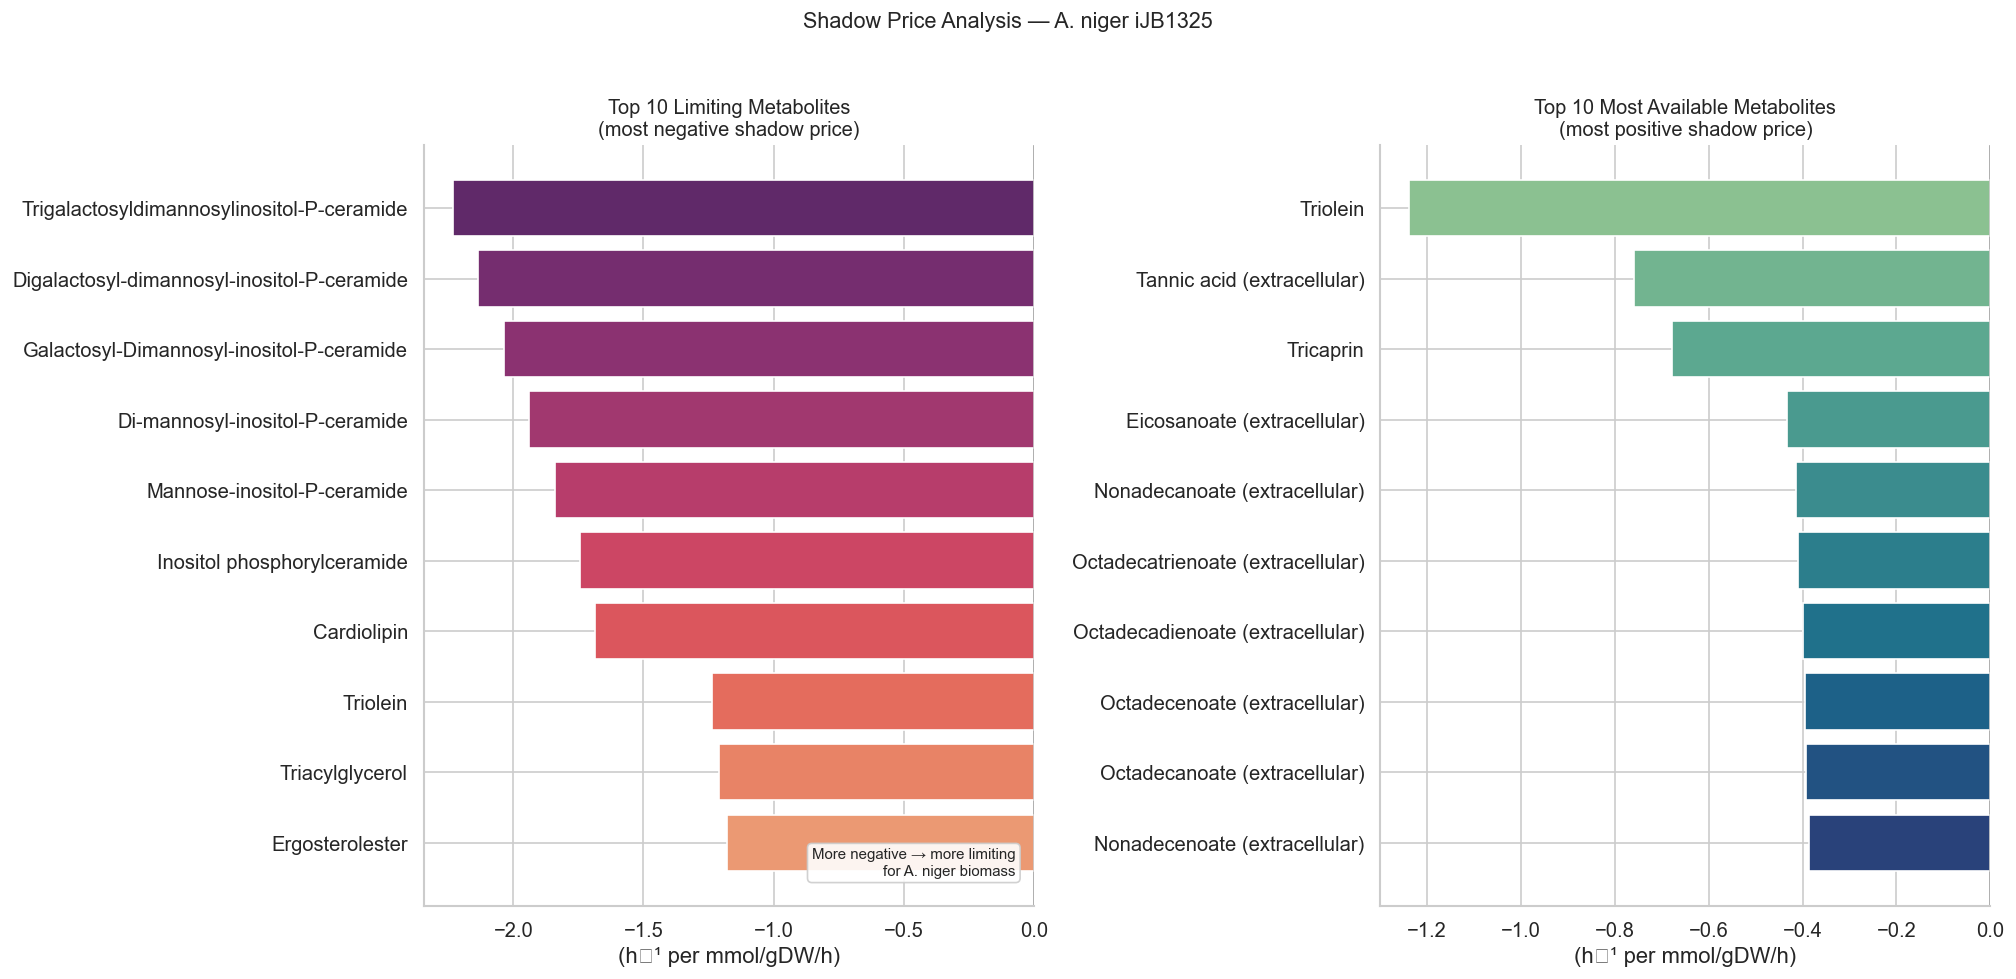

In [19]:
shadow  = fba_solution.shadow_prices.dropna()
reduced = fba_solution.reduced_costs.dropna()

shadow_nonzero = shadow[shadow.abs() > 1e-9]
print(f'Non-zero shadow prices : {len(shadow_nonzero)}')
print(f'Non-zero reduced costs : {(reduced.abs() > 1e-9).sum()}')

def met_name(mid):
    try: return An_model.metabolites.get_by_id(mid).name or mid
    except: return mid
def met_comp(mid):
    try: return An_model.metabolites.get_by_id(mid).compartment
    except: return 'n/a'

shadow_nonzero = shadow[shadow.abs() > 1e-9]

top_neg = shadow_nonzero.nsmallest(10)
df_shadow_neg = pd.DataFrame({'Metabolite'  : [met_name(i) for i in top_neg.index],
                              'ID'          : list(top_neg.index),
                              'Compartment' : [met_comp(i) for i in top_neg.index],
                              'Shadow Price': top_neg.values,})

exchangeable_mets = {m.id for rxn in An_model.exchanges for m in rxn.metabolites}
shadow_exch = shadow_nonzero[shadow_nonzero.index.isin(exchangeable_mets)]
exch_top10 = shadow_exch.nsmallest(10)

df_exch_shadow = pd.DataFrame({'Metabolite'  : [met_name(i) for i in exch_top10.index],
                               'ID'          : list(exch_top10.index),
                               'Compartment' : [met_comp(i) for i in exch_top10.index],
                               'Shadow Price': exch_top10.values})

fig, axes = plt.subplots(1, 2, figsize = (17, 8))

# Left
axes[0].barh(df_shadow_neg['Metabolite'], 
             df_shadow_neg['Shadow Price'],
             color     = sns.color_palette('flare_r', len(df_shadow_neg)), 
             edgecolor = 'white')
axes[0].axvline(0, color = 'black', lw = 0.8)
axes[0].set_xlabel('(h⁻¹ per mmol/gDW/h)')
axes[0].set_title('Top 10 Limiting Metabolites\n(most negative shadow price)', fontsize = 12)
axes[0].invert_yaxis()
axes[0].annotate('More negative → more limiting\nfor A. niger biomass',
                  xy       = (0.97,0.04), 
                  xycoords = 'axes fraction', 
                  ha       = 'right', 
                  fontsize = 9,
                  bbox     = dict(boxstyle = 'round, pad = 0.3', fc = 'white', ec = '#ccc', alpha = 0.9))

# Right
axes[1].barh(df_exch_shadow['Metabolite'], 
             df_exch_shadow['Shadow Price'],
             color     = sns.color_palette('crest', len(df_exch_shadow)), 
             edgecolor = 'white')
axes[1].axvline(0, color = 'black', lw = 0.8)
axes[1].set_xlabel('(h⁻¹ per mmol/gDW/h)')
axes[1].set_title('Top 10 Most Available Metabolites\n(most positive shadow price)', fontsize = 12)
axes[1].invert_yaxis()

plt.suptitle('Shadow Price Analysis — A. niger iJB1325', fontsize = 13, y = 1.02)
plt.tight_layout()
# plt.savefig('fig2_An_shadow_prices.png', dpi = 150, bbox_inches = 'tight')
plt.show()

### 7.2 Reduced Costs
Identify reactions with high absolute reduced costs — reactions not active in the optimal solution whose activation would decrease growth. All top reactions 
carry negative reduced costs, confirming they are at their lower bound. Notable entries include extracellular lipids, macromolecular drain reactions, and Malformine C synthesis — a mycotoxin biosynthesis reaction relevant to the infection context.

In [20]:
def rxn_name(rid):
    try: return An_model.reactions.get_by_id(rid).name[:40] or rid
    except: return rid

top_rc = reduced.abs().nlargest(15)

rxn_labels_rc = [An_model.reactions.get_by_id(i).name
                 if An_model.reactions.get_by_id(i).name
                 and An_model.reactions.get_by_id(i).name.lower() not in ('artificial reaction', 'artifical reaction')
                 else i
                 for i in top_rc.index]

df_rc = pd.DataFrame({'Reaction'    : rxn_labels_rc,
                      'ID'          : list(top_rc.index),
                      'Reduced Cost': reduced[top_rc.index].values})

print(df_rc[['Reaction', 'ID', 'Reduced Cost']].to_string(index = False))

                                                                      Reaction              ID  Reduced Cost
                                                                BOUNDARY_TRIOe  BOUNDARY_TRIOe     -2.473964
                                                                 Monooxygenase           r2339     -2.277905
                                                                 DRAIN_PROTEIN   DRAIN_PROTEIN     -2.158615
                                          Artifical protein synthesis reaction           r1265     -2.134121
                                          Artifical protein synthesis reaction           r1266     -2.123293
                                                                    DRAIN_DNAm      DRAIN_DNAm     -1.916522
                                                                DRAIN_CELLWALL  DRAIN_CELLWALL     -1.904029
                                                                 PROTEINpolymm   PROTEINpolymm     -1.616774
                   

## 8. Robustness Analysis
### 8.1 Glucose–Biomass Relationship
The glucose–biomass relationship was evaluated for linearity. The growth slope, intercept, and R² were computed, and the minimum viable glucose uptake supporting growth was identified. 

The relationship exhibits a perfectly linear response ($R² = 1.0$), with a zero intercept and a growth yield of $0.09399\ h^{-1}\ per\ mmol/gDW/h$. This indicates a strictly carbon-limited regime in which glucose uptake is the sole determinant of growth. No minimum maintenance threshold was observed, as the model enforces no explicit ATP maintenance constraint.

Infeasible: 0
Optimal   : 60

Slope (GROWTH_SLOPE_AN)         = 0.09399 h⁻¹ per mmol/gDW/h
Intercept (GROWTH_INTERCEPT_AN) = 0.00000
R² (GROWTH_R2_AN)               = 1.00000
Min viable glucose rate         = 0.0000 mmol/gDW/h


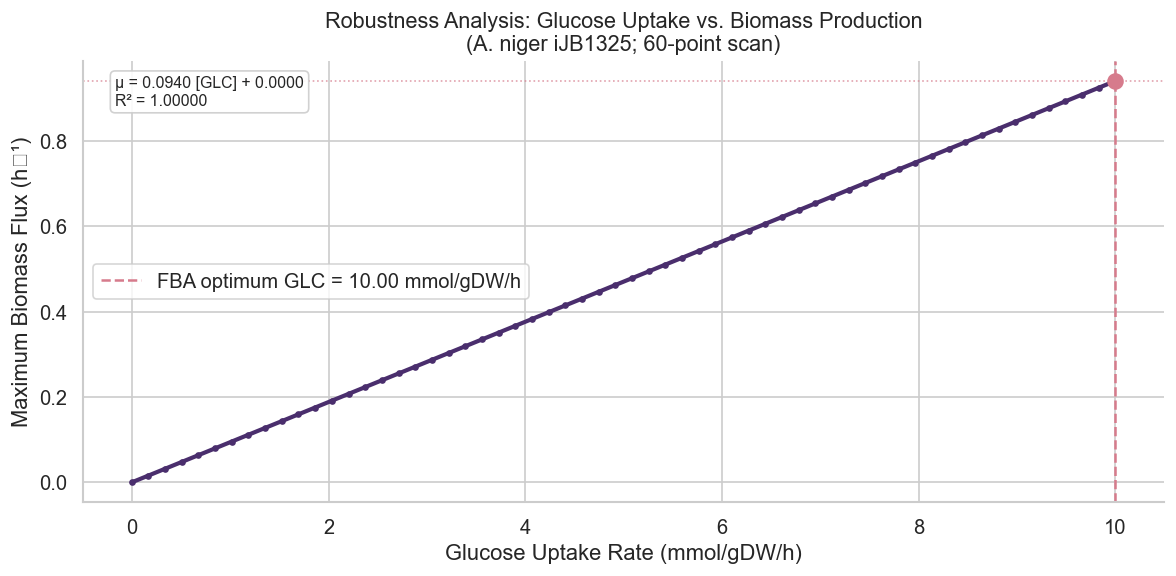

In [21]:
SCAN_MIN_AN = 0.0
SCAN_MAX_AN = 10.0
N_POINTS_AN = 60

scan_values  = np.linspace(SCAN_MIN_AN, SCAN_MAX_AN, N_POINTS_AN)
biomass_vals = []
statuses     = []

for rate in scan_values:
    with An_model:
        An_model.reactions.get_by_id(GLC_RXN).lower_bound = -rate
        sol = An_model.optimize()
        biomass_vals.append(sol.objective_value if sol.status == 'optimal' else np.nan)
        statuses.append(sol.status)

df_robust_An = pd.DataFrame({'Glucose Rate': scan_values,
                             'Biomass Flux': biomass_vals,
                             'Status'      : statuses,})
print(f'Infeasible: {df_robust_An["Status"].eq("infeasible").sum()}')
print(f'Optimal   : {df_robust_An["Status"].eq("optimal").sum()}')

valid  = df_robust_An.dropna(subset = ['Biomass Flux'])
x      = valid['Glucose Rate'].values
y      = valid['Biomass Flux'].values
coeffs = np.polyfit(x, y, 1)
y_pred = np.polyval(coeffs, x)
GROWTH_SLOPE_AN     = coeffs[0]
GROWTH_INTERCEPT_AN = coeffs[1]
GROWTH_R2_AN        = 1 - np.sum((y-y_pred)**2) / np.sum((y-y.mean())**2)

min_rate_AN = max(0.0, -GROWTH_INTERCEPT_AN / GROWTH_SLOPE_AN) if GROWTH_SLOPE_AN > 0 else 0.0

print(f'\nSlope (GROWTH_SLOPE_AN)         = {GROWTH_SLOPE_AN:.5f} h⁻¹ per mmol/gDW/h')
print(f'Intercept (GROWTH_INTERCEPT_AN) = {GROWTH_INTERCEPT_AN:.5f}')
print(f'R² (GROWTH_R2_AN)               = {GROWTH_R2_AN:.5f}')
print(f'Min viable glucose rate         = {min_rate_AN:.4f} mmol/gDW/h')

fig, ax = plt.subplots(figsize = (10, 5))
ax.plot(valid['Glucose Rate'], 
        valid['Biomass Flux'],
        color      = '#4A2E6D', 
        lw         = 2.5, 
        marker     = 'o', 
        markersize = 3)
ref_row = valid.iloc[(valid['Glucose Rate'] - GLC_BASELINE_AN).abs().argsort().iloc[0]]
ax.axvline(GLC_BASELINE_AN, 
           color = '#D67B8C', 
           ls    = '--', 
           lw    = 1.5,
           label = f'FBA optimum GLC = {GLC_BASELINE_AN:.2f} mmol/gDW/h')
ax.axhline(ref_row['Biomass Flux'], color = '#D67B8C', ls = ':', lw = 1, alpha = 0.7)
ax.scatter([GLC_BASELINE_AN], [ref_row['Biomass Flux']], color = '#D67B8C', s = 80, zorder = 5)
ax.annotate(f'μ = {GROWTH_SLOPE_AN:.4f} [GLC] + {GROWTH_INTERCEPT_AN:.4f}\n'
            f'R² = {GROWTH_R2_AN:.5f}',
            xy       = (0.03, 0.90), 
            xycoords = 'axes fraction', 
            fontsize = 9.5,
            bbox     = dict(boxstyle = 'round,pad = 0.3', fc = 'white', ec = '#ccc', alpha = 0.9))
ax.set_xlabel('Glucose Uptake Rate (mmol/gDW/h)')
ax.set_ylabel('Maximum Biomass Flux (h⁻¹)')
ax.set_title('Robustness Analysis: Glucose Uptake vs. Biomass Production\n'
             f'(A. niger iJB1325; {N_POINTS_AN}-point scan)', fontsize = 13)
ax.legend()
plt.tight_layout()
# plt.savefig('fig3_An_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Phenotypic Phase Plane
Construct a production envelope to map maximal growth as a function of oxygen uptake, identifying oxygen-limited and oxygen-saturated regimes.

An aerobic-fermentative transition was detected at O₂ ~$1.496 mmol/gDW/h$ — below this threshold, growth is strongly O₂-limited. Above it, the model enters 
a less O₂-sensitive regime, peaking at the FBA-optimum (~$7.78 mmol/gDW/h$). A slight decrease in biomass at very high O₂ rates (>10 mmol/gDW/h) suggests that excess oxidative flux marginally diverts resources away from growth.

Production envelope: 40 points
Aerobic-fermentative transition at O2 ~1.496 mmol/gDW/h
FBA-optimum O2 = 7.779 mmol/gDW/h


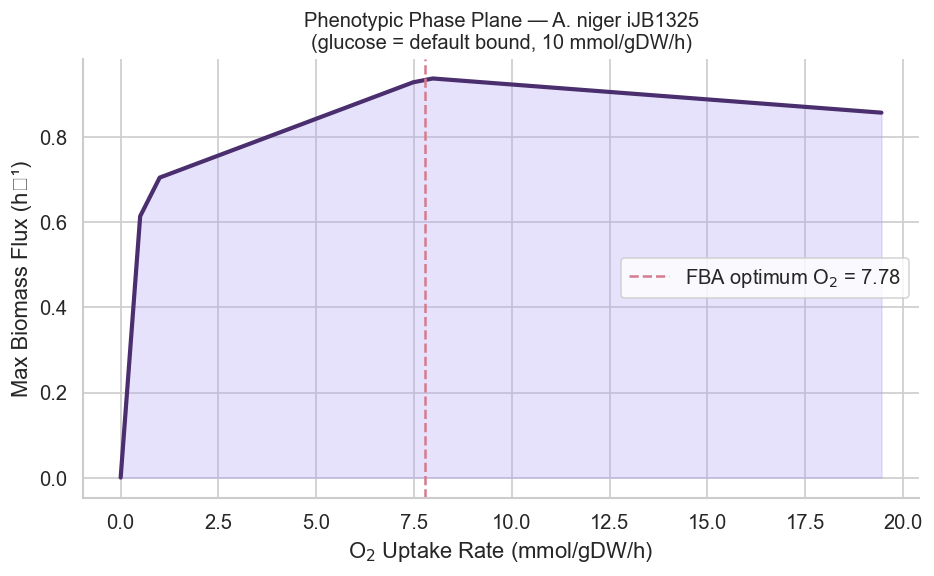

In [22]:
N_ENV_PTS   = 40
o2_scan_max = max(O2_BASELINE_AN * 2.5, 6.0)

with An_model:
    An_model.reactions.get_by_id(O2_RXN).lower_bound = -o2_scan_max
    An_model.reactions.get_by_id(O2_RXN).upper_bound = 0
    env_An = production_envelope(An_model, reactions = [O2_RXN], points = N_ENV_PTS)

o2_col = O2_RXN
mu_col = 'flux_maximum'
assert o2_col in env_An.columns, f'O2 column missing. Available: {list(env_An.columns)}'
assert mu_col in env_An.columns, f'flux_maximum missing. Available: {list(env_An.columns)}'

x_o2     = env_An[o2_col].abs()
y_mu     = env_An[mu_col]
sort_idx = np.argsort(x_o2)
x_o2     = x_o2.iloc[sort_idx].values
y_mu     = y_mu.iloc[sort_idx].values

print(f'Production envelope: {env_An.shape[0]} points')

valid_mask = ~(np.isnan(x_o2) | np.isnan(y_mu))
x_v, y_v   = x_o2[valid_mask], y_mu[valid_mask]

o2_transition_An = None
if len(x_v) > 2:
    slopes  = np.gradient(y_v, x_v)
    max_sl  = slopes.max()
    sat_idx = np.where(slopes < 0.05 * max_sl)[0] if max_sl > 0 else []
    if len(sat_idx):
        o2_transition_An = float(x_v[sat_idx[0]])

if o2_transition_An is not None:
    if abs(o2_transition_An - x_v.max()) < 0.01:
        print(f'Aerobic-fermentative transition NOT detected in scan range (>{x_v.max():.2f} mmol/gDW/h)')
    else:
        print(f'Aerobic-fermentative transition at O2 ~{o2_transition_An:.3f} mmol/gDW/h')
print(f'FBA-optimum O2 = {O2_BASELINE_AN:.3f} mmol/gDW/h')

fig, ax = plt.subplots(figsize = (8, 5))
ax.fill_between(x_o2, 0, y_mu, color = '#B19FF4', alpha = 0.3)
ax.plot(x_o2, y_mu, color = '#4A2E6D', lw = 2.5)
ax.axvline(O2_BASELINE_AN,
           color = '#D67B8C',
           ls    = '--',
           lw    = 1.5,
           label = f'FBA optimum O$_2$ = {O2_BASELINE_AN:.2f}')
ax.set_xlabel('O$_2$ Uptake Rate (mmol/gDW/h)')
ax.set_ylabel('Max Biomass Flux (h⁻¹)')
ax.set_title('Phenotypic Phase Plane — A. niger iJB1325\n'
             '(glucose = default bound, 10 mmol/gDW/h)', fontsize = 12)
ax.legend()
plt.tight_layout()
# plt.savefig('fig4_An_phpp.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. ATP Transport Directionality Curation
### 10.1 Identification
Identify ATP-associated reversible reactions as potential candidates for thermodynamically implausible backflow. Reaction `r2137` (`ATP <=> ATPp`) 
is an inter-compartment ATP transport that was selected for curation; the remaining 24 ATP-involving reversible reactions carry essential metabolic fluxes confirmed by FVA and were left unchanged.

In [23]:
candidates = []
for rxn in An_model.reactions:
    involves_atp = any('atp' in met.id.lower() for met in rxn.metabolites)
    is_reversible = rxn.lower_bound < 0 and rxn.upper_bound > 0
    if involves_atp and is_reversible:
        candidates.append({'ID'      : rxn.id,
                           'Name'    : rxn.name,
                           'LB'      : rxn.lower_bound,
                           'UB'      : rxn.upper_bound,
                           'Equation': rxn.reaction[:80],})
df_atp = pd.DataFrame(candidates)
print(f'ATP-involving reversible reactions: {len(df_atp)}')
print(df_atp.to_string()) 

r2137_flux = fba_solution.fluxes.get('r2137', 0)

fva_r2137 = flux_variability_analysis(An_model,
                                       reaction_list       = ['r2137'],
                                       fraction_of_optimum = 1.0,
                                       processes           = 1)

ATP-involving reversible reactions: 25
       ID                                                                          Name      LB      UB                   Equation
0     r15                                                       Phosphoglycerate kinase -1000.0  1000.0  13PDG + ADP <=> 3PG + ATP
1     r60                                                                Acetate kinase -1000.0  1000.0    AC + ATP <=> ACTP + ADP
2    r436                                                              Adenylate kinase -1000.0  1000.0      AMP + ATP <=> 2.0 ADP
3    r438                                                 Adenylate kinase, dAMP kinase -1000.0  1000.0  ATP + DAMP <=> ADP + DADP
4    r439                                                 Nucleoside-diphosphate kinase -1000.0  1000.0  ATP + DADP <=> ADP + DATP
5    r442                                                              Guanylate kinase -1000.0  1000.0    ATP + GMP <=> ADP + GDP
6    r443                                   

### 10.2 Curation
Constrain `r2137` to unidirectional flux ($lower bound = 0$) to prevent thermodynamically implausible backflow of peroxisomal ATP.

**r2137 — ATP → ATPp (cytosol → peroxisome):**
Originally reversible in *iJB1325* (lower bound = $−1000$), allowing the thermodynamically implausible reverse flux $ATPp → ATP$. Lower bound set to $0$ to enforce unidirectional transport. Growth rate unaffected ($μ = 0.9399 h⁻¹$).

In [24]:
mu_before = An_model.optimize().objective_value

r2137 = An_model.reactions.get_by_id('r2137')

print(f'r2137 before : lb = {r2137.lower_bound}, ub = {r2137.upper_bound}')
print(f'Equation     : {r2137.reaction}')
print(f'r2137 — ATP inter-compartment transport:')
print(f'    Flux at FBA optimum : {r2137_flux:.4f} mmol/gDW/h')
print(f'    FVA minimum         : {fva_r2137.loc["r2137", "minimum"]:.4f} mmol/gDW/h')
print(f'    FVA maximum         : {fva_r2137.loc["r2137", "maximum"]:.4f} mmol/gDW/h')

r2137.lower_bound = 0.0

mu_after = An_model.optimize().objective_value
print(f'\nμ before curation  : {mu_before:.4f} h⁻¹')
print(f'μ after curation   : {mu_after:.4f} h⁻¹')
print(f'Change             : {mu_after - mu_before:+.4f} h⁻¹')

fba_solution = An_model.optimize()
print(f'\nPost-curation FBA status: {fba_solution.status}')

assert abs(mu_after - mu_before) < 1e-4, f'Unexpected μ change: {mu_before:.4f} -> {mu_after:.4f}'

r2137 before : lb = -1000.0, ub = 1000.0
Equation     : ATP <=> ATPp
r2137 — ATP inter-compartment transport:
    Flux at FBA optimum : 0.0000 mmol/gDW/h
    FVA minimum         : -1000.0000 mmol/gDW/h
    FVA maximum         : 1000.0000 mmol/gDW/h

μ before curation  : 0.9399 h⁻¹
μ after curation   : 0.9399 h⁻¹
Change             : -0.0000 h⁻¹

Post-curation FBA status: optimal


## 11. Export and Validation
Export the curated model in SBML format (`An_curated.xml`) and perform a round-trip validation to ensure structural and functional consistency. FBA was re-run after re-import, and growth rate consistency was confirmed.

In [25]:
final_sol = An_model.optimize()
assert final_sol.status == 'optimal', 'Curated model infeasible.'
print(f'Curated model status : {final_sol.status}')
print(f'Biomass flux (μ)     : {final_sol.objective_value:.4f} h⁻¹')

Curated model status : optimal
Biomass flux (μ)     : 0.9399 h⁻¹


In [26]:
EXPORT_PATH_AN = 'An_curated.xml'
write_sbml_model(An_model, EXPORT_PATH_AN)
print(f'Exported: {EXPORT_PATH_AN}  ({os.path.getsize(EXPORT_PATH_AN)/1024:.1f} kB)')

_rt        = read_sbml_model(EXPORT_PATH_AN)
_rt_sol    = _rt.optimize()
_rt_r2137  = _rt.reactions.get_by_id('r2137')

assert _rt_sol.status == 'optimal',                                     'Round-trip model infeasible.'
assert abs(_rt_sol.objective_value - final_sol.objective_value) < 1e-6, 'Round-trip μ mismatch.'
assert 'e' in _rt.compartments,                                         'Extracellular compartment missing.'
assert _rt_r2137.lower_bound == 0.0,                                    'r2137 curation lost in round-trip.'
assert len(_rt.reactions)    == len(An_model.reactions),                'Reaction count mismatch!'
assert len(_rt.metabolites)  == len(An_model.metabolites),              'Metabolite count mismatch!'

print('Round-trip integrity check PASSED')
print(f'  μ          : {final_sol.objective_value:.4f} → {_rt_sol.objective_value:.4f}')
print(f'  r2137 lb   : {_rt_r2137.lower_bound}')
print(f'  Reactions  : {len(_rt.reactions)}')
print(f'  Metabolites: {len(_rt.metabolites)}')

Exported: An_curated.xml  (4166.1 kB)


'' is not a valid SBML 'SId'.


Round-trip integrity check PASSED
  μ          : 0.9399 → 0.9399
  r2137 lb   : 0.0
  Reactions  : 2320
  Metabolites: 1818


## 12. Model Limitations

1. **Unconstrained growth rate:** The default $μ = 0.9399 h⁻¹$ reflects open exchange bounds and is not physiologically representative of infection conditions.
2. **No infection-specific constraints:** The model represents saprophytic growth; infection-related regulatory and secretion mechanisms are not explicitly captured at the constraint-based level.
3. **Organic acid secretion pathways:** Under the default glucose-limited medium, secretion of gluconate, oxalate and citrate was not observed at the FBA optimum. These pathways may be activated under alternative carbon sources or pH conditions not represented in this model.
4. **Mass balance errors:** $71$ internal reactions carry unresolved stoichiometric discrepancies, predominantly in lipid acyltransferases and lumped pathways.
5. **Unbounded reactions:** $58$ reactions reach default bounds under FVA (fraction = 0.0), indicating potential thermodynamic cycles that may cause numerical instability in dynamic simulations.
6. **ATP inter-compartment transport (r2137):** Constrained to unidirectional flux to prevent thermodynamically implausible backflow of peroxisomal ATP. No effect on μ was observed.

## 13. References

* **iJB1325** (Brandl et al., 2018)

Brandl, J., Aguilar-Pontes, M. V., Schäpe, P., Nørregaard, A., Arvas, M., Ram, A. F. J., Meyer, V., Tsang, A., de Vries, R. P., & Andersen, M. R. (2018). A community-driven reconstruction of the *Aspergillus niger* metabolic network. *Fungal Biology and Biotechnology*, *5*, 16. https://doi.org/10.1186/s40694-018-0060-7